Feature matrix: (1000, 1024)
Label vector: (1000,)

--- Model Evaluation Results ---
              Model  Accuracy  Precision  Recall  F1-score
Logistic Regression     0.840   0.840000    0.84  0.840000
                SVM     0.765   0.778947    0.74  0.758974


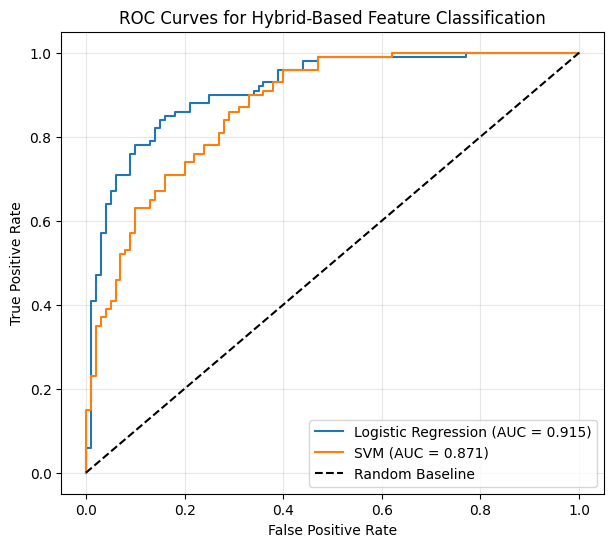

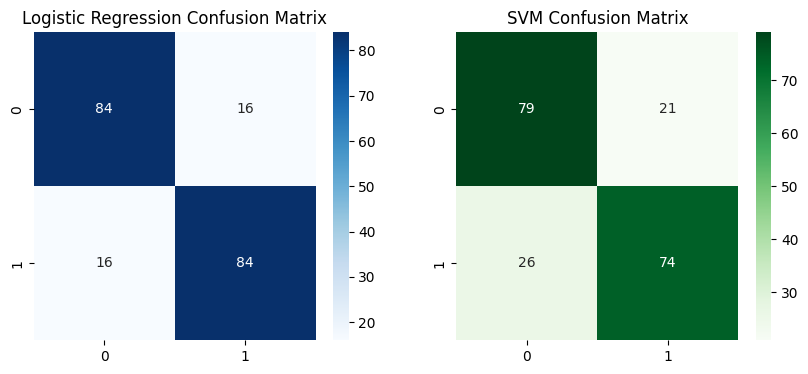

In [1]:
# --- Imports ---
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    pairwise_distances, confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.fft import fft
import pywt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# --- Load SSL Features ---
with open("hybrid_features.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
y = np.array(data["labels"])

print("Feature matrix:", X.shape)
print("Label vector:", y.shape)

# --- Split dataset ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Train Classifiers ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_score_lr = log_reg.decision_function(X_test)

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
y_score_svm = svm.decision_function(X_test)

# --- Evaluation Function with Table Output ---
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_models(y_true, y_pred_lr, y_pred_svm):
    # Compute metrics for each model
    results = {
        "Model": ["Logistic Regression", "SVM"],
        "Accuracy": [
            accuracy_score(y_true, y_pred_lr),
            accuracy_score(y_true, y_pred_svm)
        ],
        "Precision": [
            precision_score(y_true, y_pred_lr, zero_division=0),
            precision_score(y_true, y_pred_svm, zero_division=0)
        ],
        "Recall": [
            recall_score(y_true, y_pred_lr, zero_division=0),
            recall_score(y_true, y_pred_svm, zero_division=0)
        ],
        "F1-score": [
            f1_score(y_true, y_pred_lr, zero_division=0),
            f1_score(y_true, y_pred_svm, zero_division=0)
        ]
    }

    # Convert to DataFrame for cleaner display
    df_results = pd.DataFrame(results)
    print("\n--- Model Evaluation Results ---")
    print(df_results.to_string(index=False))

# Run evaluation
evaluate_models(y_test, y_pred_lr, y_pred_svm)


# --- ROC Curves ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_score_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Baseline")
plt.title("ROC Curves for Hybrid-Based Feature Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt="d", ax=axes[1], cmap="Greens")
axes[1].set_title("SVM Confusion Matrix")
plt.show()
